In [9]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score


In [10]:
X= 6*np.random.rand(200,1)-3
y=0.8*X**2+0.9*X+2+np.random.randn(200,1)

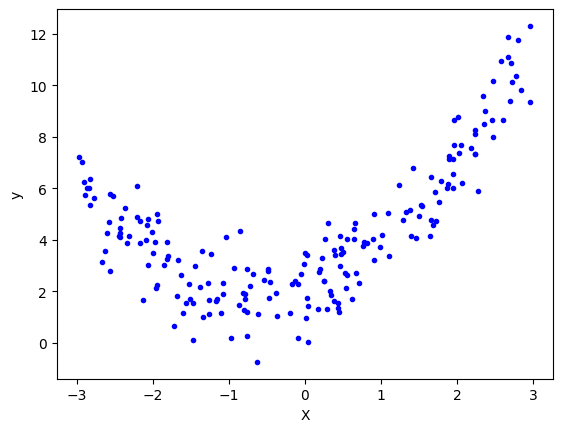

In [11]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()


In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)


In [15]:
print(r2_score(y_test,y_pred))

0.32336933423319747


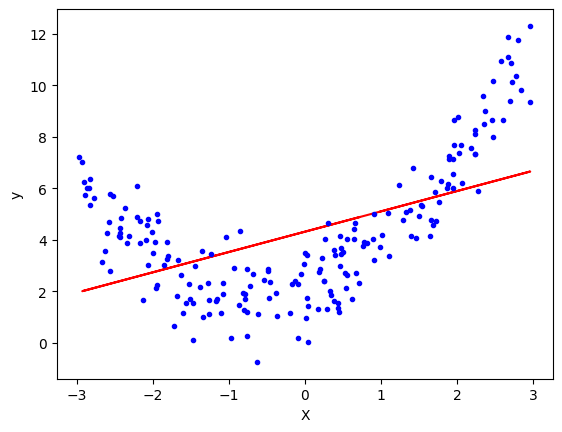

In [16]:
plt.plot(X_train,lr.predict(X_train),'r-')
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [22]:
poly=PolynomialFeatures(degree=2,include_bias=False)
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)

In [23]:
print(X_train[0])
print(X_train_trans[0])

[0.71718536]
[0.71718536 0.51435483]


In [25]:
lr11=LinearRegression()
lr11.fit(X_train_trans,y_train)
y_pred=lr11.predict(X_test_trans)
print(r2_score(y_test,y_pred))

0.8844068423291456


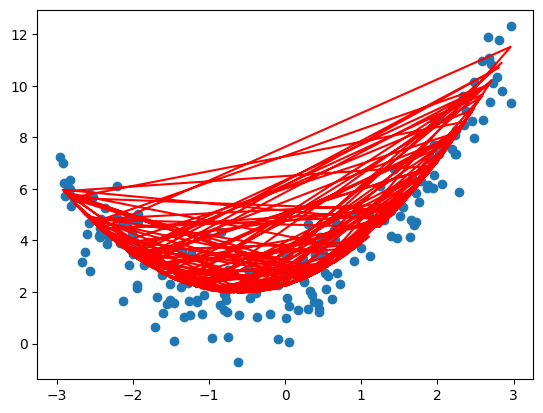

In [26]:
plt.scatter(X,y)
plt.plot(X_train,lr11.predict(X_train_trans),'r-')

In [27]:
print(lr11.coef_,lr11.intercept_)

[[0.91452071 0.74886284]] [2.23979343]


In [28]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
y_new=lr11.predict(X_new_poly)

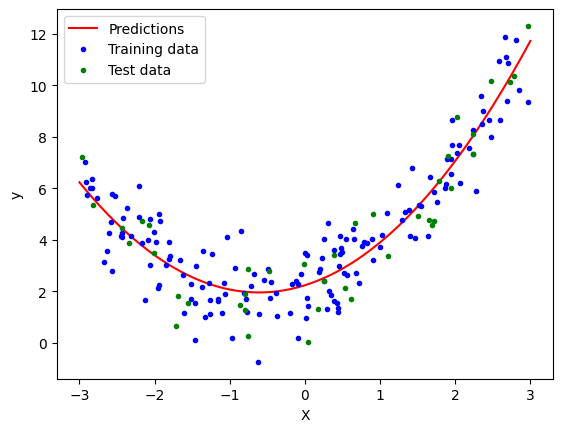

In [29]:
plt.plot(X_new,y_new,'r-',label='Predictions')
plt.plot(X_train,y_train,'b.',label='Training data')
plt.plot(X_test,y_test,'g.',label='Test data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [30]:
def polynomial_regression(degree):
    X_new=np.linspace(-3,3,100).reshape(100,1)
    X_new_poly=poly.transform(X_new)
    polybig_features=PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler=StandardScaler()
    lin_reg=LinearRegression()
    polynomial_regression=Pipeline([
        ("poly_features",polybig_features),
        ("std_scaler",std_scaler),
        ("lin_reg",lin_reg)
    ])
    polynomial_regression.fit(X,y)
    y_newbig=polynomial_regression.predict(X_new)
    plt.plot(X_new,y_newbig,'r',label="Degree"+str(degree),linewidth=2)
    plt.plot(X_train,y_train,'b.',linewidth=3)
    plt.plot(X_test,y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.axis([-3,3,0,10])
    plt.show()

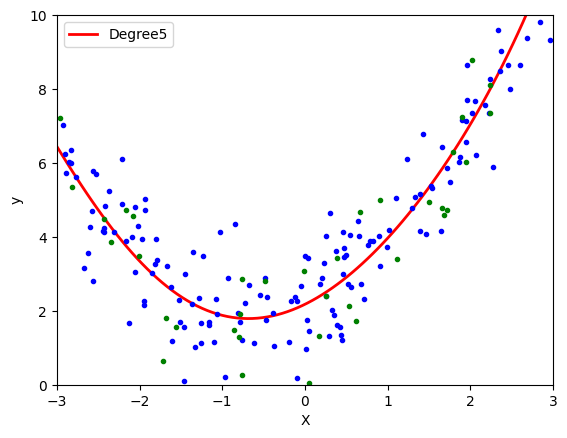

In [40]:
polynomial_regression(5)

In [41]:
x=7*np.random.rand(100,1)-3.5
y=7*np.random.rand(100,1)-3.5
z=0.5*x**2+0.5*y**2+np.random.randn(100,1)

In [43]:
!pip install plotly
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df,x='sepal_length',y='sepal_width',z='petal_length',color='species') 
fig.show()

  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 8.5 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 10.5 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.9 MB 9.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 8.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 8.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.1 MB/s  0:00:01
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   --------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
lr=LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)
x_input=np.linspace(x.min(),x.max(),10)
y_input=np.linspace(y.min(),y.max(),10)
xGrid,yGrid=np.meshgrid(x_input,y_input)
final = np.vstack([xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100)]).T
z_final=lr.predict(final).reshape(10,10)

In [46]:
import plotly.graph_objects as go
fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_traces(go.Surface(x=x_input,y=y_input,z=z_final,colorscale='Viridis',opacity=0.5))
fig.show()